# The label PPO would not keep

`13` closed with one label still missing. On the tool line the policy computes the flow loss exactly --
`numeric_acc` is 0.988 at step 200 -- and never once writes the action that a flow loss past -30% requires:
`isolate_and_evaluate_replacement`, 0 of 37 dev cases, in the frozen policy and after 200 PPO steps alike.
That caps `exact_match` at `(200-37)/200 = 0.815` and the run reached 0.555.

This notebook installs the label by supervision and hands it back to reinforcement learning, which is `10`'s
argument tested where `10` could not test it: on the tool line, from the raw model, with the arithmetic in the
policy rather than in the harness.

**What PPO does with a seeded label depends on how often the label is right when it is said.** A seed that says
the severe action on 77 of 600 sampled slots and is right on 21 of them -- 27% -- does not survive: 150 steps
later the policy says it 5 times on dev and the label is gone by step 178. In the same run
`organic_fouling`, seeded at one correct emission in 600, goes to **29 of 29 with no false positive**. One
label is deleted; `organic_fouling`, seeded at a single correct emission in 600, is amplified to **29 of 29 with
no false positive** in the run from that seed that went the distance. One label is kept and the other removed by
the same objective, and what separates them is how often each was right when the seed said it.

**Paying 3x for a correct severe action reverses the deletion.** `--severe-credit-scale 3.0` -- `09`'s lever
for `flat`, applied to the action slot -- takes the same label to **37 of 37 on the sealed test split**, with
`exact_match` **0.855 dev / 0.825 test / 0.740 on the distribution-shift holdout**, against `13`'s 0.555. The
grader is untouched: the credit moves reward *within* an episode, `reward.score` is what every number here
reports.

**A per-token discount is what let a run reach 200 steps at all.** At `gamma = 1` the run stopped on its
sampled-arithmetic rule at step 178, at `gamma = 0.99` at step 85; at **`gamma = 0.999` it ran the full 200 and
reached 0.635**. Lowering the arithmetic stop from 0.90 to 0.80 to see whether 0.99 was stopped too early
answered no: by step 100 held-out `numeric_acc` was 0.668 and `exact_match` 0.005.

In [1]:
import json, sys
from pathlib import Path
import matplotlib.pyplot as plt

HERE = Path.cwd() if (Path.cwd() / "ppo_ac.py").exists() else Path("experiments/notebooks/smoke_test")
RUNS, SEED = HERE / "runs", HERE / "runs" / "severe-seed"
GRPO = (HERE / ".." / ".." / "membrane_grpo").resolve()
sys.path.insert(0, str(HERE.resolve()))
sys.path.insert(0, str(GRPO))  # read-only, as everywhere in this lane
from task.schema import parse_answer

SEVERE = "isolate_and_evaluate_replacement"
DEV = {r["id"]: r for r in (json.loads(l) for l in (GRPO / "data" / "dev.jsonl").read_text().splitlines() if l.strip())}
N_SEVERE = sum(r["answer"]["action"] == SEVERE for r in DEV.values())
N_ORGANIC = sum(r["answer"]["root_cause"] == "organic_fouling" for r in DEV.values())

def envelope(name, where=SEED):
    """One `eval_only` envelope: `overall` is eval.py's summary, `probe` counts the two labels."""
    return json.load(open(where / f"{name}.json"))

def evals(run):
    return [json.loads(l) for l in (RUNS / run / "eval.jsonl").read_text().splitlines() if l.strip()]

def metrics(run):
    return [json.loads(l) for l in (RUNS / run / "metrics.jsonl").read_text().splitlines() if l.strip()]

def label_counts(path):
    """Greedy emissions of the two labels, parsed out of a saved episodes file."""
    said = {"severe": 0, "severe_right": 0, "organic": 0, "organic_right": 0}
    for line in Path(path).read_text().splitlines():
        if not line.strip():
            continue
        ep = json.loads(line)
        obj = parse_answer(ep["text"]).obj or {}
        truth = DEV[ep["id"]]["answer"]
        if obj.get("action") == SEVERE:
            said["severe"] += 1
            said["severe_right"] += truth["action"] == SEVERE
        if obj.get("root_cause") == "organic_fouling":
            said["organic"] += 1
            said["organic_right"] += truth["root_cause"] == "organic_fouling"
    return said

print(f"dev: {len(DEV)} cases, the severe action is the answer on {N_SEVERE}, organic_fouling on {N_ORGANIC}")
print(f"with the severe action never said, exact_match cannot pass {(len(DEV) - N_SEVERE) / len(DEV):.3f}")

dev: 200 cases, the severe action is the answer on 37, organic_fouling on 29
with the severe action never said, exact_match cannot pass 0.815


## Where `13` left the two labels

`10` found both `organic_fouling` and the severe action at exactly zero probability under the v3 prompt. The
tool line is a different policy -- v2's prompt, a calculator, a supervised pass that teaches only the three
calls -- so the first thing to establish is which of the two is still dead here. They are not in the same
state, and only one of them is a *label* problem.

In [2]:
rows = [("raw model + calculator", RUNS / "tool" / "raw_dev.episodes.jsonl"),
        ("+ tool SFT (13b's start)", RUNS / "tool" / "sft_raw_dev.episodes.jsonl"),
        ("12, step 125", RUNS / "tool" / "warm200_best125_dev.episodes.jsonl"),
        ("13b, step 200", SEED / "dev_13b_s0_final.episodes.jsonl")]
print(f"  {'policy':28}{'severe said':>13}{'right':>7}{'organic said':>15}{'right':>7}")
for name, path in rows:
    c = label_counts(path)
    print(f"  {name:28}{c['severe']:>13}{c['severe_right']:>7}{c['organic']:>15}{c['organic_right']:>7}")
print()
print(f"  the answer on {N_SEVERE} and {N_ORGANIC} of the {len(DEV)} cases respectively")
print()
print("  organic_fouling is not dead on this line: the raw model says it, and PPO takes it to 29 of 29.")
print("  The severe action is said zero times by every one of these policies -- including the one whose")
print("  arithmetic is exact, which is what makes it a label problem rather than a capability problem.")

  policy                        severe said  right   organic said  right
  raw model + calculator                  0      0              2      0
  + tool SFT (13b's start)                0      0              8      5
  12, step 125                            0      0             29     29
  13b, step 200                           0      0             79     29

  the answer on 37 and 29 of the 200 cases respectively

  organic_fouling is not dead on this line: the raw model says it, and PPO takes it to 29 of 29.
  The severe action is said zero times by every one of these policies -- including the one whose
  arithmetic is exact, which is what makes it a label problem rather than a capability problem.


## A seed that installs a label without moving anything else

Supervision can put mass on a string a policy would never sample, which is the whole of `10`'s argument. What
`10` did not have to worry about is a second turn: on this line the episode is calls, then the calculator's
reply, then the answer, and the seed's gradient reaches all of it through shared weights.

Three designs, each measured on 64 dev cases with the gold first turn teacher-forced. The quantities are the
probability that the answer turn *opens with the answer* rather than with another `<tool_call>`, and the mean
entropy over the gold call tokens -- how peaked the policy is on the calls it has already learned.

In [3]:
margin = json.load(open(SEED / "turn2_margin.json"))
call_h = {"tool seed": envelope("dev_toolsftraw")["overall"]["call_entropy"],
          "action + calls anchored, 1 epoch": envelope("dev_calls_epoch1")["overall"].get("call_entropy"),
          "joint, action only, 1 epoch": envelope("dev_joint_epoch1")["overall"]["call_entropy"],
          "joint, both slots, 3 epochs": envelope("dev_slots_epoch3")["overall"]["call_entropy"]}

print(f"  {'policy':36}{'P(answer opens)':>17}{'P(another call)':>17}{'call entropy':>14}")
for row in margin["policies"]:
    h = call_h.get(row["policy"])
    print(f"  {row['policy']:36}{row['p_answer_mean']:>17.3f}{row['p_call_mean']:>17.3f}"
          f"{(f'{h:.6f}' if h else '-'):>14}")
print(f"\n  {margin['n_cases']} dev cases, teacher-forced")
print()
print("  Supervising the action value alone moves a token it never touches: the answer turn stops opening")
print("  with the answer (0.975 -> 0.014) and the policy re-issues its calls until the budget runs out.")
print("  Adding the answer's first token to the loss fixes that, and the calls then loosen instead --")
print("  4x the tool seed's entropy, which greedy decoding cannot see. The seed that holds supervises the")
print("  three gold calls as well, and the one used from here on does it in a single pass from the raw")
print("  model: the tool seed's own examples and the label seed together, so neither drifts while the")
print("  other is learned.")

  policy                                P(answer opens)  P(another call)  call entropy
  raw                                             0.995            0.000             -
  tool seed                                       0.975            0.007      0.000252
  action-only seed, 1 epoch                       0.014            0.952             -
  action + calls anchored, 1 epoch                0.993            0.002             -
  joint, action only, 1 epoch                     0.999            0.000      0.000465
  joint, both slots, 3 epochs                     0.999            0.000      0.000223

  64 dev cases, teacher-forced

  Supervising the action value alone moves a token it never touches: the answer turn stops opening
  with the answer (0.975 -> 0.014) and the policy re-issues its calls until the budget runs out.
  Adding the answer's first token to the loss fixes that, and the calls then loosen instead --
  4x the tool seed's entropy, which greedy decoding cannot see. The

## Choosing a dose

The seed is 150 records from `11`'s off-distribution set -- generated to a brief, never drawn from any split of
the task, labelled by the grader's own function -- carried through the gold tool episode. Supervised: the three
calls, the answer's first token, and the value of `action` (and, in the last seed, `root_cause`). Nothing else:
not the numbers, not the flags, not the stage.

Five criteria, fixed before each sweep ran, with a checkpoint per epoch as the dose:

| | |
| --- | --- |
| (a) | the severe action is said at least once where it is the answer, and — after the first PPO run — with precision ≥ 0.40 |
| (b) | it is said on at most 10% of the samples whose answer is not severe |
| (c) | greedy dev `numeric_acc` ≥ 0.99 |
| (d) | sampled `numeric_acc` ≥ 0.90, the run's own stop rule |
| (e) | teacher-forced call entropy ≤ 2x the tool seed's |

Sampling is what the criteria read, not greedy decoding: PPO trains on samples, and the two disagree sharply.

In [4]:
seeds = [("tool seed (13b's start)", "probe_epoch0", "dev_toolsftraw"),
         ("joint, action only, 1 ep", "probe_joint_epoch1", "dev_joint_epoch1"),
         ("joint, action only, 2 ep", "probe_joint_epoch2", "dev_joint_epoch2"),
         ("joint, both slots, 2 ep", "probe_slots_epoch2", "dev_slots_epoch2"),
         ("joint, both slots, 3 ep", "probe_slots_epoch3", "dev_slots_epoch3")]
print(f"  {'seed':28}{'severe said/right':>19}{'prec':>7}{'FP':>7}{'organic said/right':>20}{'sampled num':>13}{'greedy severe':>15}")
for name, pr, dv in seeds:
    p = envelope(pr)["probe"]
    o = envelope(pr)["overall"]
    g = envelope(dv)["probe"]
    prec = p["severe_correct"] / p["severe_emitted"] if p["severe_emitted"] else 0.0
    fp = (p["severe_emitted"] - p["severe_correct"]) / (p["samples"] - p["severe_slots"])
    print(f"  {name:28}{p['severe_emitted']:>12}/{p['severe_correct']:<6}{prec:>7.0%}{fp:>7.1%}"
          f"{p['og_emitted']:>13}/{p['og_correct']:<6}{o['numeric_acc']:>13.3f}"
          f"{g['severe_emitted']:>10}/{g['severe_correct']:<4}")
print(f"\n  temperature 1.0, 150 train cases x 4 samples; the severe action is the answer on"
      f" {envelope('probe_epoch0')['probe']['severe_slots']} of those 600 slots, organic_fouling on"
      f" {envelope('probe_epoch0')['probe']['og_slots']}")
print()
print("  Dose and mask buy emissions, not precision: 22-45% across every seed measured. And greedy")
print("  flatters badly -- the both-slots 2-epoch seed says the severe action 5 times greedily and is")
print("  right all 5, while at temperature 1.0 it is right 22% of the time.")

  seed                          severe said/right   prec     FP  organic said/right  sampled num  greedy severe
  tool seed (13b's start)                1/0          0%   0.2%           48/27            0.996         0/0   
  joint, action only, 1 ep              77/21        27%  11.4%            1/1             0.994        26/2   
  joint, action only, 2 ep              56/25        45%   6.3%            0/0             0.996         3/3   
  joint, both slots, 2 ep               80/18        22%  12.6%           65/31            0.991         5/5   
  joint, both slots, 3 ep               78/21        27%  11.6%           96/43            0.993        11/6   

  temperature 1.0, 150 train cases x 4 samples; the severe action is the answer on 108 of those 600 slots, organic_fouling on 80

  Dose and mask buy emissions, not precision: 22-45% across every seed measured. And greedy
  flatters badly -- the both-slots 2-epoch seed says the severe action 5 times greedily and is
  right al

## What PPO does with a barely-alive label

The first PPO run starts from the 1-epoch action-only seed: the severe action right 21 times in 600 samples,
`organic_fouling` right once. Everything else is `13b`'s configuration -- qwen-agent harness, answer-scoped
entropy, dense per-field credit, `lam = 0.95` -- so the start is the only change, and the value head is
initialised at the seed's own held-out reward rather than the tool seed's.

In [5]:
before, after = envelope("dev_joint_epoch1"), envelope("dev_ppo_joint_g1_best150")
ev = evals("ppo-tool-joint-seed-200")
print(f"  {'':22}{'exact':>8}{'cause':>8}{'action':>8}   severe said/right   organic said/right")
for name, e in (("the seed", before), ("PPO, step 150", after)):
    o, p = e["overall"], e["probe"]
    print(f"  {name:22}{o['exact_match']:>8.3f}{o['cause_acc']:>8.3f}{o['action_acc']:>8.3f}"
          f"{p['severe_emitted']:>13}/{p['severe_correct']:<6}{p['og_emitted']:>13}/{p['og_correct']}")
print()
print("  held out every 25 steps:", "  ".join(f"{r['step']}: {r['exact_match']:.3f}" for r in ev))
print()
print("  The severe action goes from 26 emissions with 2 right to 5 with 3: PPO removed the wrong ones")
print("  rather than learning where the label belongs, and the run stopped on its sampled-arithmetic rule")
print("  at step 178. organic_fouling, at one correct emission in the seed, is gone here too -- what the")
print("  next section shows is that this is the run, not the seed: from the same seed a discounted run")
print("  takes organic_fouling to 29 of 29.")

                           exact   cause  action   severe said/right   organic said/right
  the seed                 0.080   0.325   0.215           26/2                 1/1
  PPO, step 150            0.305   0.440   0.425            5/3                 0/0

  held out every 25 steps: 0: 0.085  25: 0.055  50: 0.045  75: 0.180  100: 0.235  125: 0.225  150: 0.305  175: 0.185

  The severe action goes from 26 emissions with 2 right to 5 with 3: PPO removed the wrong ones
  rather than learning where the label belongs, and the run stopped on its sampled-arithmetic rule
  at step 178. organic_fouling, at one correct emission in the seed, is gone here too -- what the
  next section shows is that this is the run, not the seed: from the same seed a discounted run
  takes organic_fouling to 29 of 29.


Seeding put the string in the vocabulary and the reward took it back out. A label that is wrong three times
in four contributes negatively on average, and a mode-seeking update answers that by not saying it -- which is
exactly what `10` predicted a policy gradient would do with a label it cannot place, one layer further on.

## The discount, and the rule that stops the run

Every run on this line so far has ended the same way: the sampled arithmetic decays until the last-ten-step
mean falls under 0.90 and the run stops itself. A per-token discount changes how far a reward reaches back
towards the calls, so it is the one knob that touches that decay without changing the prompt or the reward.

Three values from the same seed, nothing else changed, plus one run that asks whether the stop rule is too
strict.

In [6]:
runs = [("gamma 1", "ppo-tool-joint-seed-200"), ("gamma 0.99", "ppo-tool-joint-seed-200-g099"),
        ("gamma 0.999", "ppo-tool-joint-seed-200-g0999"), ("13b, seed 0", "ppo-tool-qwen-agent-scoped-200")]
print(f"  {'step':>5}" + "".join(f"{n:>14}" for n, _ in runs))
curves = {n: {r["step"]: r["exact_match"] for r in evals(p)} for n, p in runs}
for s in range(0, 201, 25):
    print(f"  {s:>5}" + "".join(f"{curves[n][s]:>14.3f}" if s in curves[n] else f"{'-':>14}" for n, _ in runs))
print()
for name, path in runs[:3]:
    m = metrics(path)
    w = [x for x in m if x["step"] >= len(m) - 20]
    print(f"  {name:12} ran to step {m[-1]['step']:>3}, call entropy over its last 20 steps"
          f" {sum(x['entropy_proxy_calls'] for x in w) / len(w):.5f}")
print()
print("  0.999 is the only one of the three that reached 200 steps, and it is 0.08 above 13b's two seeds")
print("  (0.555, 0.560). Not because its calls stayed sharper -- they end looser than either run that")
print("  stopped. The stop rule reads the sampled arithmetic, and that is what held here and did not there.")
print("  One trajectory each, and two runs of an identical command differ by 0.12 at step 50 on this line,")
print("  so this ranks these runs, not the values of gamma.")

   step       gamma 1    gamma 0.99   gamma 0.999   13b, seed 0
      0         0.085         0.085         0.085         0.065
     25         0.055         0.125         0.155         0.190
     50         0.045         0.225         0.230         0.195
     75         0.180         0.300         0.290         0.290
    100         0.235             -         0.310         0.320
    125         0.225             -         0.485         0.415
    150         0.305             -         0.560         0.465
    175         0.185             -         0.635         0.545
    200             -             -         0.635         0.555

  gamma 1      ran to step 178, call entropy over its last 20 steps 0.00203
  gamma 0.99   ran to step  85, call entropy over its last 20 steps 0.00254
  gamma 0.999  ran to step 199, call entropy over its last 20 steps 0.00611

  0.999 is the only one of the three that reached 200 steps, and it is 0.08 above 13b's two seeds
  (0.555, 0.560). Not because it

In [7]:
seed_e, done = envelope("dev_joint_epoch1"), envelope("dev_ppo_joint_g0999_final")
print(f"  {'':26}{'exact':>8}   severe said/right   organic said/right")
for name, e in (("the seed", seed_e), ("gamma 0.999, step 200", done)):
    o, p = e["overall"], e["probe"]
    print(f"  {name:26}{o['exact_match']:>8.3f}{p['severe_emitted']:>13}/{p['severe_correct']:<6}"
          f"{p['og_emitted']:>13}/{p['og_correct']}")
print()
print("  This is the asymmetry, in one run and one gradient. organic_fouling is decided by a flag the")
print("  policy already writes correctly, so a single correct emission is a template the reward can")
print("  reinforce -- 29 of 29, no false positive. The severe action is decided by a threshold on a number")
print("  the policy reproduces exactly, and it is still said in the wrong place three times out of four,")
print("  so the same objective removes it. Rarity is not what separates them; precision is.")

                               exact   severe said/right   organic said/right
  the seed                     0.080           26/2                 1/1
  gamma 0.999, step 200        0.635            0/0                29/29

  This is the asymmetry, in one run and one gradient. organic_fouling is decided by a flag the
  policy already writes correctly, so a single correct emission is a template the reward can
  reinforce -- 29 of 29, no false positive. The severe action is decided by a threshold on a number
  the policy reproduces exactly, and it is still said in the wrong place three times out of four,
  so the same objective removes it. Rarity is not what separates them; precision is.


In [8]:
low = evals("ppo-tool-joint-seed-200-g099-stop080")
print("  gamma 0.99 again, with the arithmetic stop lowered from 0.90 to 0.80:")
print(f"  {'step':>6}{'exact':>8}{'numeric':>9}{'cause':>8}{'flags':>8}")
for r in low:
    print(f"  {r['step']:>6}{r['exact_match']:>8.3f}{r['numeric_acc']:>9.3f}{r['cause_acc']:>8.3f}{r['flags_acc']:>8.3f}")
m = metrics("ppo-tool-joint-seed-200-g099-stop080")
nums = [x["train_numeric_acc"] for x in m]
print(f"\n  at its last step the sampled mean over ten steps was {sum(nums[-10:]) / 10:.3f} -- above 0.80, so the")
print("  run was still allowed to continue while held-out exact_match was 0.005. There is nothing to")
print("  recover between the two thresholds: 0.90 stops the run at the point where the policy is still worth")
print("  keeping, which is what a stop rule is for.")

  gamma 0.99 again, with the arithmetic stop lowered from 0.90 to 0.80:
    step   exact  numeric   cause   flags
       0   0.085    1.000   0.315   0.690
      25   0.110    1.000   0.345   0.760
      50   0.105    1.000   0.355   0.722
      75   0.170    0.997   0.375   0.885
     100   0.005    0.668   0.160   0.675

  at its last step the sampled mean over ten steps was 0.808 -- above 0.80, so the
  run was still allowed to continue while held-out exact_match was 0.005. There is nothing to
  recover between the two thresholds: 0.90 stops the run at the point where the policy is still worth
  keeping, which is what a stop rule is for.


## Paying for the label

`09` met this shape once before. `flat` was the right answer in 184 of 600 flag slots and the policy emitted it
three times; a 3x credit for a correct `flat` took its recall to 0.984 and `exact_match` from 0.145 to 0.405.
The severe action is the same shape one slot down, so it gets the same lever: `--severe-credit-scale 3.0` pays
0.45 instead of 0.15 for a correct severe action and leaves every other case untouched. It is dense credit
*within* the episode -- `reward.score`, which produces every number in this notebook, does not change.

The seed is the both-slots, 3-epoch one: the only seed measured with both labels alive, and with calls sharper
than the tool seed's own. It fails criterion (b) at 11.6%.

In [9]:
seed_e, best = envelope("dev_slots_epoch3"), envelope("dev_credit_best125")
print(f"  {'':22}{'exact':>8}{'cause':>8}{'action':>8}{'flags':>8}   severe said/right   organic said/right")
for name, e in (("the seed", seed_e), ("PPO + 3x, step 125", best)):
    o, p = e["overall"], e["probe"]
    print(f"  {name:22}{o['exact_match']:>8.3f}{o['cause_acc']:>8.3f}{o['action_acc']:>8.3f}{o['flags_acc']:>8.3f}"
          f"{p['severe_emitted']:>13}/{p['severe_correct']:<6}{p['og_emitted']:>13}/{p['og_correct']}")
print()
print("  held out every 25 steps:", "  ".join(f"{r['step']}: {r['exact_match']:.3f}" for r in evals("ppo-tool-severe-credit-200")))
print()
for split, name in (("dev", "dev_credit_best125"), ("test", "test_credit_best125"),
                    ("holdout_shift", "holdout_shift_credit_best125")):
    e = envelope(name)
    o, p = e["overall"], e["probe"]
    print(f"  {split:14}{o['n_cases']:>5} cases   exact {o['exact_match']:.3f}   cause {o['cause_acc']:.3f}"
          f"   numeric {o['numeric_acc']:.3f}   severe {p['severe_correct']}/{p['severe_slots']}"
          f"   organic {p['og_correct']}/{p['og_slots']}")
print()
print("  test and holdout_shift were not used to select anything here; the 0.030 dev-test gap is the cost of")
print("  choosing the checkpoint on dev, in line with the 0.020-0.030 the earlier notebooks measured.")

                           exact   cause  action   flags   severe said/right   organic said/right
  the seed                 0.065   0.365   0.295   0.562           11/6                27/11
  PPO + 3x, step 125       0.855   0.950   0.955   0.955           38/36               29/29

  held out every 25 steps: 0: 0.065  25: 0.345  50: 0.490  75: 0.760  100: 0.810  125: 0.855

  dev             200 cases   exact 0.855   cause 0.950   numeric 0.990   severe 36/37   organic 29/29
  test            200 cases   exact 0.825   cause 0.925   numeric 0.992   severe 37/37   organic 27/29
  holdout_shift    50 cases   exact 0.740   cause 0.820   numeric 0.993   severe 10/10   organic 5/8

  test and holdout_shift were not used to select anything here; the 0.030 dev-test gap is the cost of
  choosing the checkpoint on dev, in line with the 0.020-0.030 the earlier notebooks measured.


In [10]:
m = metrics("ppo-tool-severe-credit-200")
print(f"  {'window':>10}{'critic vs clock':>18}{'ahead':>8}{'call entropy':>14}{'sampled numeric':>17}")
for lo in range(0, 141, 25):
    w = [x for x in m if lo <= x["step"] < lo + 25]
    if not w:
        continue
    d = [x["value_ev"] - x["value_ev_position"] for x in w]
    print(f"  {f'{lo}-{lo + len(w) - 1}':>10}{sum(d) / len(d):>+18.4f}{f'{sum(x > 0 for x in d)}/{len(d)}':>8}"
          f"{sum(x['entropy_proxy_calls'] for x in w) / len(w):>14.5f}"
          f"{sum(x['train_numeric_acc'] for x in w) / len(w):>17.3f}")
print()
print("  The critic clears the position-only clock from step 25 rather than step 50, which is earlier than")
print("  any run in 13, and the calls stay at the seed's own sharpness for the first 50 steps. The run still")
print("  stops on sampled arithmetic, at step 141; the checkpoint kept is step 125.")

      window   critic vs clock   ahead  call entropy  sampled numeric
        0-24           -0.0869    3/25       0.00003            0.998
       25-49           +0.0071   21/25       0.00003            1.000
       50-74           +0.0195   25/25       0.00115            0.990
       75-99           +0.0282   23/25       0.00076            0.988
     100-124           +0.0349   25/25       0.00032            0.995
     125-141           +0.0195   14/17       0.00099            0.922

  The critic clears the position-only clock from step 25 rather than step 50, which is earlier than
  any run in 13, and the calls stay at the seed's own sharpness for the first 50 steps. The run still
  stops on sampled arithmetic, at step 141; the checkpoint kept is step 125.


## The two labels, side by side

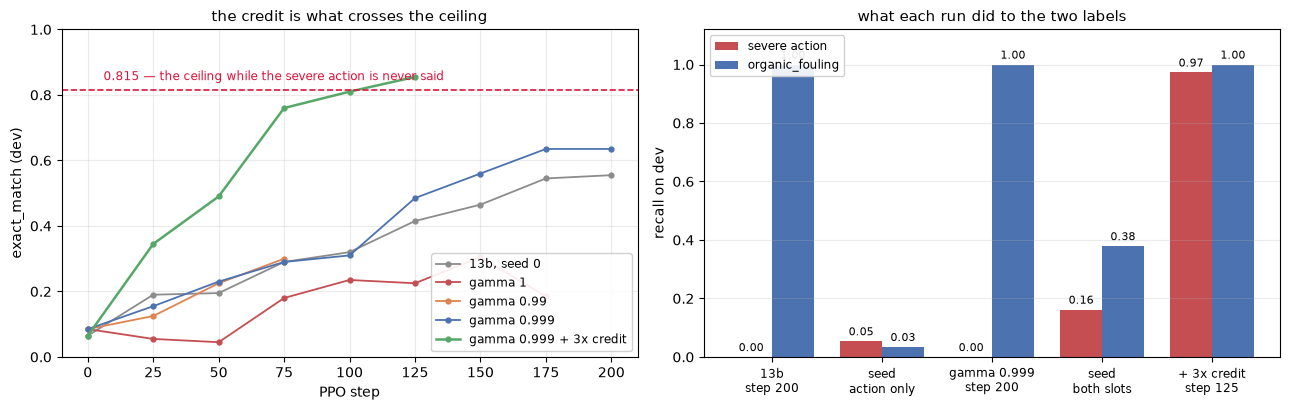

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

series = [("13b, seed 0", "ppo-tool-qwen-agent-scoped-200", "0.55", "-"),
          ("gamma 1", "ppo-tool-joint-seed-200", "#c44e52", "-"),
          ("gamma 0.99", "ppo-tool-joint-seed-200-g099", "#dd8452", "-"),
          ("gamma 0.999", "ppo-tool-joint-seed-200-g0999", "#4c72b0", "-"),
          ("gamma 0.999 + 3x credit", "ppo-tool-severe-credit-200", "#55a868", "-")]
for label, run, colour, style in series:
    e = evals(run)
    ax1.plot([r["step"] for r in e], [r["exact_match"] for r in e], style, color=colour, marker="o",
             ms=3.5, lw=1.8 if "credit" in label else 1.3, label=label)
ax1.axhline((len(DEV) - N_SEVERE) / len(DEV), color="crimson", ls="--", lw=1.2)
ax1.text(6, (len(DEV) - N_SEVERE) / len(DEV) + .03, "0.815 — the ceiling while the severe action is never said",
         color="crimson", fontsize=8.5)
ax1.set_xlabel("PPO step"); ax1.set_ylabel("exact_match (dev)"); ax1.set_ylim(0, 1.0)
ax1.legend(fontsize=8.5, loc="lower right", framealpha=.9)
ax1.set_title("the credit is what crosses the ceiling", fontsize=10.5); ax1.grid(alpha=.25)

pairs = [("13b\nstep 200", envelope("dev_13b_s0_final")),
         ("seed\naction only", envelope("dev_joint_epoch1")),
         ("gamma 0.999\nstep 200", envelope("dev_ppo_joint_g0999_final")),
         ("seed\nboth slots", envelope("dev_slots_epoch3")),
         ("+ 3x credit\nstep 125", envelope("dev_credit_best125"))]
x = range(len(pairs))
sev = [e["probe"]["severe_correct"] / N_SEVERE for _, e in pairs]
org = [e["probe"]["og_correct"] / N_ORGANIC for _, e in pairs]
ax2.bar([i - .19 for i in x], sev, width=.38, color="#c44e52", label="severe action")
ax2.bar([i + .19 for i in x], org, width=.38, color="#4c72b0", label="organic_fouling")
for i, (s, o) in enumerate(zip(sev, org)):
    ax2.text(i - .19, s + .02, f"{s:.2f}", ha="center", fontsize=8)
    ax2.text(i + .19, o + .02, f"{o:.2f}", ha="center", fontsize=8)
ax2.set_xticks(list(x)); ax2.set_xticklabels([n for n, _ in pairs], fontsize=8.5)
ax2.set_ylabel("recall on dev"); ax2.set_ylim(0, 1.12)
ax2.legend(fontsize=8.5, loc="upper left", framealpha=.9)
ax2.set_title("what each run did to the two labels", fontsize=10.5); ax2.grid(alpha=.25, axis="y")

fig.tight_layout()
fig.savefig(RUNS / "severe_seed_and_credit.png", dpi=140)
plt.show()

## What this leaves

**The mechanism from `09` and `10` now has its third case, and a sharper statement.** Three times the binding
constraint was a string the policy would not say. What this notebook adds is what happens *after* the string is
installed: reinforcement learning keeps a rare label when the label is usually right where it appears and
deletes it when it is not, and the deletion is not a failure of the seed's size -- 77 emissions were plenty --
but of its precision. The remedy that works is the one `09` already found, which is to pay more for the times
it is right.

**The task is at 0.825 on a split nothing selected on**, with both labels recalled (37 of 37 and 27 of 29) and
the arithmetic in the policy rather than in the harness -- the thing `08`'s v3 was withdrawn for. The remaining
29 non-exact dev cases miss `flags.salt_passage` 14 times and `root_cause` 10 times; the two labels this
notebook is about account for 3.

**What is not shown.** One trajectory per discount value, on a line where two runs of an identical command
differ by 0.12 `exact_match` at step 50 -- the ordering of 0.99, 0.999 and 1 is not established, only that
0.999 completed and reached the highest score. The credit run has no control at the same seed without the
credit, so "the credit did it" rests on the mechanism and on `09`'s precedent rather than on a paired run. And
every run on this line still ends on the sampled-arithmetic rule between steps 140 and 180, which is the next
thing to understand.